# <font color = #699F04>**Modelo de Cox para Sobrevida em Câncer Colorretal**</font>

Notebook de modelagem estatística da sobrevida de pacientes com câncer colorretal, dando continuidade aos artefatos gerados em `Pre_Processamento_dos_Dados.ipynb`.

**Fluxo do notebook**

Carregamento dos dados tratados ➤ Preparação das variáveis ➤ Codificação dos preditores ➤ Ajuste do modelo de Cox ➤ Validação das hipóteses ➤ Predição e métricas ➤ Visualizações


## <font color = #B88A00>**Configuração Inicial**</font>


### <font color = #007EF5>**Dependências**</font>


Dependências utilizadas neste notebook:
- `json`
- `pathlib.Path`
- `warnings`
- `numpy`
- `pandas`
- `matplotlib.pyplot`
- `seaborn`
- `IPython.display`
- `sklearn.metrics.mean_absolute_error`
- `sklearn.metrics.mean_squared_error`
- `sklearn.preprocessing.OneHotEncoder`
- `sklearn.preprocessing.OrdinalEncoder`
- `lifelines.CoxPHFitter`
- `lifelines.KaplanMeierFitter`
- `lifelines.calibration.survival_probability_calibration`
- `lifelines.statistics.multivariate_logrank_test`
- `lifelines.statistics.proportional_hazard_test`
- `sksurv.metrics.concordance_index_ipcw`
- `sksurv.metrics.integrated_brier_score`
- `sksurv.util.Surv`


### <font color = #007EF5>**Importações e Paths**</font>


In [1]:
# Importações utilizadas ao longo de todo o notebook
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.calibration import survival_probability_calibration
from lifelines.statistics import multivariate_logrank_test, proportional_hazard_test
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sksurv.metrics import concordance_index_ipcw, integrated_brier_score
from sksurv.util import Surv

# Configuração visual e de caminhos do projeto
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='DataFrame Index is not unique, defaulting to incrementing index instead.')
sns.set_theme(style='whitegrid', palette='crest')

TRAIN_DATA_PATH = Path('../data/processed/train_data_2025.csv')
TEST_DATA_PATH = Path('../data/processed/test_data_2025.csv')
METADATA_PATH = Path('../data/processed/dataset_metadata_2025.json')


## <font color = #B88A00>**Carregamento dos Dados Tratados**</font>


### <font color = #007EF5>**Leitura dos Arquivos**</font>


In [2]:
# Leitura dos artefatos gerados no notebook de pré-processamento
df_train = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
df_test = pd.read_csv(TEST_DATA_PATH, low_memory=False)

with open(METADATA_PATH, encoding='utf-8') as file:
    metadata = json.load(file)


### <font color = #007EF5>**Visão Geral dos Conjuntos**</font>


In [3]:
# Resumo estrutural dos conjuntos de treino e teste
dataset_summary = pd.DataFrame(
    {
        'Linhas': [df_train.shape[0], df_test.shape[0]],
        'Colunas': [df_train.shape[1], df_test.shape[1]],
        'Taxa de evento': [df_train['event'].mean(), df_test['event'].mean()],
        'Tempo mediano (meses)': [df_train['time'].median(), df_test['time'].median()]
    },
    index=['Treino', 'Teste']
)

display(dataset_summary.round(4))
display(df_train.head(3))


,Linhas,Colunas,Taxa de evento,Tempo mediano (meses)
Treino,26131,17,0.5554,36.0
Teste,6533,17,0.5553,37.0


,INSTITU,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,TOPO,ECGRUP,ANODIAG,HABILIT,nDRS,CONSDIAG_CAT,TRATCONS_CAT,DIAGTRAT_CAT,MORFO_CAT,time,event
0,21636,2,67,1,2,2,C209,III,2016,1,6,3,0,2,Adenocarcinoma,61,0
1,20621,9,29,2,2,2,C186,III,2019,2,3,3,0,1,Adenocarcinoma,61,0
2,20737,2,64,1,9,2,C180,IV,2004,1,15,3,3,3,Adenocarcinoma,2,1


#### <font color = #FF120A>**Metadados**</font>


In [4]:
# Exibição dos metadados salvos na etapa de pré-processamento
metadata_summary = pd.DataFrame.from_dict(metadata, orient='index', columns=['Valor'])
display(metadata_summary)


,Valor
total_samples,32664
train_samples,26131
test_samples,6533
n_predictors,15
predictor_columns,"[INSTITU, ESCOLARI, IDADE, SEXO, CATEATEND, DI..."
target_columns,"[time, event]"
total_events,18140
event_rate,0.555351
time_min_months,1
time_max_months,61


## <font color = #B88A00>**Preparação para Modelagem**</font>


### <font color = #007EF5>**Definição das Variáveis**</font>


In [5]:
# Definição das colunas usadas na modelagem de sobrevivência
survival_cols = metadata['target_columns']
predictor_cols = metadata['predictor_columns']
ordinal_col = 'ECGRUP'
onehot_cols = ['TOPO', 'MORFO_CAT']

print(f'Colunas alvo: {survival_cols}')
print(f'Quantidade de preditoras: {len(predictor_cols)}')
print(f'Preditoras: {predictor_cols}')

Colunas alvo: ['time', 'event']
Quantidade de preditoras: 15
Preditoras: ['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'CATEATEND', 'DIAGPREV', 'TOPO', 'ECGRUP', 'ANODIAG', 'HABILIT', 'nDRS', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT', 'MORFO_CAT']


### <font color = #007EF5>**Verificações de Consistência**</font>


In [6]:
# Resumo de consistência dos dados de entrada
consistency_summary = pd.DataFrame(
    {
        'Treino': [
            df_train[predictor_cols + survival_cols].isna().sum().sum(),
            df_train[predictor_cols].select_dtypes(include='object').shape[1],
            df_train['event'].mean(),
            df_train['time'].min(),
            df_train['time'].max()
        ],
        'Teste': [
            df_test[predictor_cols + survival_cols].isna().sum().sum(),
            df_test[predictor_cols].select_dtypes(include='object').shape[1],
            df_test['event'].mean(),
            df_test['time'].min(),
            df_test['time'].max()
        ]
    },
    index=[
        'Valores ausentes',
        'Variáveis categóricas',
        'Taxa de evento',
        'Tempo mínimo',
        'Tempo máximo'
    ]
)

display(consistency_summary.round(4))


,Treino,Teste
Valores ausentes,0.0000,0.0000
Variáveis categóricas,3.0000,3.0000
Taxa de evento,0.5554,0.5553
Tempo mínimo,1.0000,1.0000
Tempo máximo,61.0000,61.0000


## <font color = #B88A00>**Codificação das Variáveis**</font>


### <font color = #007EF5>**Identificação das Colunas Categóricas**</font>


In [7]:
# Planejamento da codificação das variáveis categóricas
categorical_cols = df_train[predictor_cols].select_dtypes(include='object').columns.tolist()
encoding_plan = pd.DataFrame(
    {
        'Tratamento': ['OrdinalEncoder', 'OneHotEncoder', 'OneHotEncoder'],
        'Categorias no treino': [
            ', '.join(df_train[ordinal_col].value_counts().sort_index().index.tolist()),
            df_train['TOPO'].nunique(),
            df_train['MORFO_CAT'].nunique()
        ]
    },
    index=[ordinal_col, *onehot_cols]
)

print(f'Colunas categóricas identificadas: {categorical_cols}')
display(encoding_plan)


Colunas categóricas identificadas: ['TOPO', 'ECGRUP', 'MORFO_CAT']


,Tratamento,Categorias no treino
ECGRUP,OrdinalEncoder,"I, II, III, IV"
TOPO,OneHotEncoder,12
MORFO_CAT,OneHotEncoder,4


### <font color = #007EF5>**Aplicação dos Encoders**</font>


In [8]:
# Função de codificação ajustada apenas com o conjunto de treinamento
def encode_datasets(df_train, df_test):
    """
    Descrição:
      Codifica as variáveis categóricas do modelo de Cox com ajuste exclusivo no treino.

    Retorno:
      tuple[pd.DataFrame, pd.DataFrame, list[str]]
        Conjuntos codificados de treino e teste, além das colunas geradas pelo one-hot.
    """

    # Cópia dos conjuntos para preservar os dados originais
    train_encoded = df_train.copy().reset_index(drop=True)
    test_encoded = df_test.copy().reset_index(drop=True)

    # Codificação ordinal do estadiamento clínico
    ordinal_encoder = OrdinalEncoder(categories=[['I', 'II', 'III', 'IV']])
    train_encoded[[ordinal_col]] = ordinal_encoder.fit_transform(train_encoded[[ordinal_col]])
    test_encoded[[ordinal_col]] = ordinal_encoder.transform(test_encoded[[ordinal_col]])

    # Codificação one-hot das variáveis nominais
    onehot_encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    train_onehot = onehot_encoder.fit_transform(train_encoded[onehot_cols])
    test_onehot = onehot_encoder.transform(test_encoded[onehot_cols])

    onehot_feature_names = onehot_encoder.get_feature_names_out(onehot_cols).tolist()
    train_onehot_df = pd.DataFrame(np.asarray(train_onehot), columns=onehot_feature_names, index=train_encoded.index)
    test_onehot_df = pd.DataFrame(np.asarray(test_onehot), columns=onehot_feature_names, index=test_encoded.index)

    train_encoded = pd.concat([train_encoded.drop(columns=onehot_cols), train_onehot_df], axis=1)
    test_encoded = pd.concat([test_encoded.drop(columns=onehot_cols), test_onehot_df], axis=1)

    return train_encoded, test_encoded, onehot_feature_names


In [9]:
# Aplicação da codificação com ajuste exclusivo no conjunto de treino
df_train_encoded, df_test_encoded, onehot_feature_names = encode_datasets(df_train, df_test)

print(f'Treino codificado: {df_train_encoded.shape}')
print(f'Teste codificado: {df_test_encoded.shape}')
display(df_train_encoded.head(3))


Treino codificado: (26131, 29)
Teste codificado: (6533, 29)


,INSTITU,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,ECGRUP,ANODIAG,HABILIT,nDRS,...,TOPO_C185,TOPO_C186,TOPO_C187,TOPO_C188,TOPO_C189,TOPO_C199,TOPO_C209,MORFO_CAT_Anel de sinete,MORFO_CAT_Indiferenciado,MORFO_CAT_Mucinoso
0,21636,2,67,1,2,2,2.0,2016,1,6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,20621,9,29,2,2,2,2.0,2019,2,3,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,20737,2,64,1,9,2,3.0,2004,1,15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### <font color = #007EF5>**Comparação entre Estruturas**</font>


In [10]:
# Comparação da estrutura antes e depois da codificação
encoding_summary = pd.DataFrame(
    {
        'Treino original': [df_train.shape[1], len(predictor_cols), len(categorical_cols)],
        'Treino codificado': [df_train_encoded.shape[1], df_train_encoded.drop(columns=survival_cols).shape[1], 0],
        'Teste codificado': [df_test_encoded.shape[1], df_test_encoded.drop(columns=survival_cols).shape[1], 0]
    },
    index=['Total de colunas', 'Colunas preditoras', 'Colunas categóricas']
)

new_columns_summary = pd.DataFrame({'Colunas geradas pelo one-hot': onehot_feature_names})

display(encoding_summary)
display(new_columns_summary)


,Treino original,Treino codificado,Teste codificado
Total de colunas,17,29,29
Colunas preditoras,15,27,27
Colunas categóricas,3,0,0


,Colunas geradas pelo one-hot
0,TOPO_C181
1,TOPO_C182
2,TOPO_C183
3,TOPO_C184
4,TOPO_C185
5,TOPO_C186
6,TOPO_C187
7,TOPO_C188
8,TOPO_C189
9,TOPO_C199


## <font color = #B88A00>**Ajuste do Modelo de Cox**</font>


### <font color = #007EF5>**Fit do Modelo**</font>


In [11]:
# Ajuste do modelo de Cox com estratificação nas variáveis clínicas selecionadas
cph = CoxPHFitter(penalizer=0.01)

# Definição das variáveis de estratificação com base nas validações anteriores do modelo
strata_cols = ['DIAGPREV', 'TRATCONS_CAT', 'CONSDIAG_CAT']

cph.fit(
    df_train_encoded,
    duration_col='time',
    event_col='event',
    strata=strata_cols
)


<lifelines.CoxPHFitter: fitted with 26131 total observations, 11619 right-censored observations>

### <font color = #007EF5>**Sumário do Modelo**</font>


In [12]:
# Exibição do sumário do modelo ajustado
cph.print_summary()


model,lifelines.CoxPHFitter
duration col,'time'
event col,'event'
penalizer,0.01
l1 ratio,0.0
strata,"[DIAGPREV, TRATCONS_CAT, CONSDIAG_CAT]"
baseline estimation,breslow
number of observations,26131
number of events observed,14512
partial log-likelihood,-108120.46
time fit was run,2026-04-05 19:31:37 UTC


### <font color = #007EF5>**Calibração em 60 Meses**</font>


O gráfico de calibração compara a probabilidade <font color = #888B90>**prevista**</font> de sobreviver até 60 meses com a probabilidade <font color = #F54927>**observada**</font>.

- <font color = #888B90>**Curva prevista:**</font> estimativa produzida pelo modelo de Cox.
- <font color = #F54927>**Curva observada:**</font> comportamento empírico da sobrevivência no conjunto avaliado.
- <font color = #FBE7A1>**Leitura prática:**</font> quanto mais próxima da diagonal de referência, melhor a calibração.


Calibração no conjunto de treinamento


C:\Users\jv070\AppData\Roaming\Python\Python314\site-packages\lifelines\calibration.py:45: RuntimeWarning: divide by zero encountered in log
  return np.log(-np.log(1 - p))
C:\Users\jv070\AppData\Roaming\Python\Python314\site-packages\lifelines\fitters\mixins.py:20: RuntimeWarning: invalid value encountered in subtract
  return self.relu(x - knot) ** 3 - (lambda_ * self.relu(x - min_knot) ** 3 + (1 - lambda_) * self.relu(x - max_knot) ** 3)


ICI =  0.01507430969056194
E50 =  0.016415542398344307
Calibração no conjunto de teste


C:\Users\jv070\AppData\Roaming\Python\Python314\site-packages\lifelines\calibration.py:45: RuntimeWarning: divide by zero encountered in log
  return np.log(-np.log(1 - p))
C:\Users\jv070\AppData\Roaming\Python\Python314\site-packages\lifelines\fitters\mixins.py:20: RuntimeWarning: invalid value encountered in subtract
  return self.relu(x - knot) ** 3 - (lambda_ * self.relu(x - min_knot) ** 3 + (1 - lambda_) * self.relu(x - max_knot) ** 3)


ICI =  0.01479763948121764
E50 =  0.015004010743139506


(<Axes: title={'center': 'Smoothed calibration curve of \npredicted vs observed probabilities of t ≤ 60 mortality'}, xlabel='Predicted probability of \nt ≤ 60 mortality', ylabel='Observed probability of \nt ≤ 60 mortality'>,
 np.float64(0.01479763948121764),
 np.float64(0.015004010743139506))

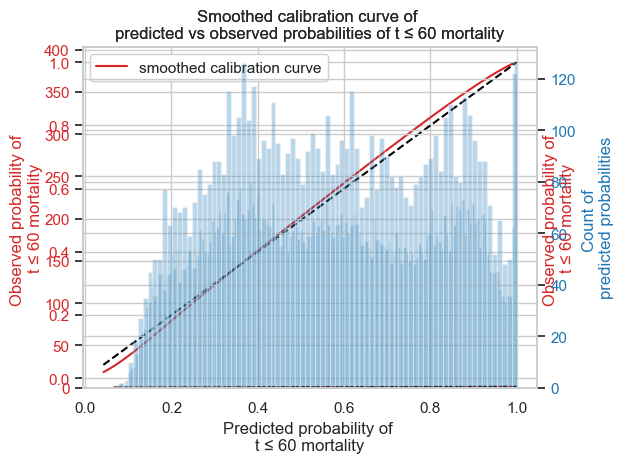

In [13]:
# Avaliação visual da calibração no horizonte de 60 meses
print('Calibração no conjunto de treinamento')
survival_probability_calibration(cph, df_train_encoded, t0=60)

print('Calibração no conjunto de teste')
survival_probability_calibration(cph, df_test_encoded, t0=60)


## <font color = #B88A00>**Validação do Modelo**</font>


### <font color = #007EF5>**Teste de Proporcionalidade de Schoenfeld**</font>


In [14]:
# Teste de proporcionalidade calculado apenas no conjunto de treinamento
ph_test = proportional_hazard_test(
    cph,                    # modelo ajustado
    df_train_encoded,       # DataSet
    time_transform = 'rank' # rank dos tempos (default)
)
display(ph_test.summary)

,test_statistic,p,-log2(p)
ANODIAG,0.014282,9.048739e-01,0.144211
CATEATEND,3.620238,5.708069e-02,4.130853
DIAGTRAT_CAT,2.637007,1.044000e-01,3.259806
ECGRUP,0.447309,5.036155e-01,0.989605
ESCOLARI,21.667977,3.241578e-06,18.234872
HABILIT,2.874551,8.999005e-02,3.474091
IDADE,5.760943,1.638628e-02,5.931368
INSTITU,25.838231,3.712614e-07,21.361061
MORFO_CAT_Anel de sinete,1.201093,2.731034e-01,1.872481
MORFO_CAT_Indiferenciado,0.193148,6.603092e-01,0.598786



   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'INSTITU' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'INSTITU' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'INSTITU' using pd.cut, and then specify it in
`strata=['INSTITU', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


2. Variable 'ESCOLARI' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 6), you can include `strata=['ESCOLARI', ...]` in the
call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


3. Variable 'IDADE' fa

C:\Users\jv070\AppData\Roaming\Python\Python314\site-packages\lifelines\fitters\mixins.py:123: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()



9. Variable 'TOPO_C209' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['TOPO_C209', ...]` in the
call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazar

[[<Axes: xlabel='rank-transformed time\n(p=0.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0648)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0164)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0003)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5944)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0080)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0571)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2235)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5036)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2071)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9049)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6377)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0900)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5759)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1268)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0066)'>],
 [<Axes: xlabel='rank-transformed tim

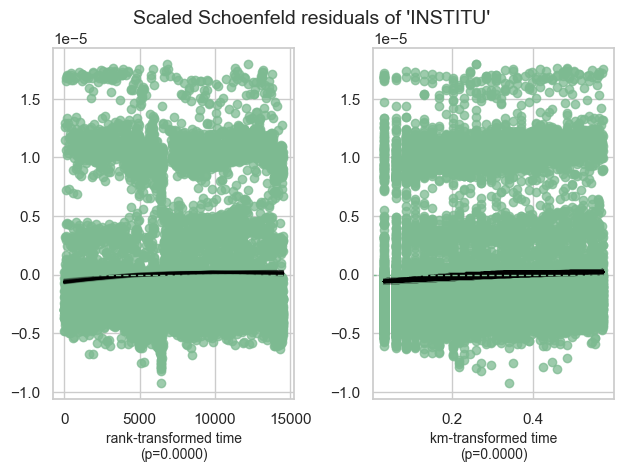

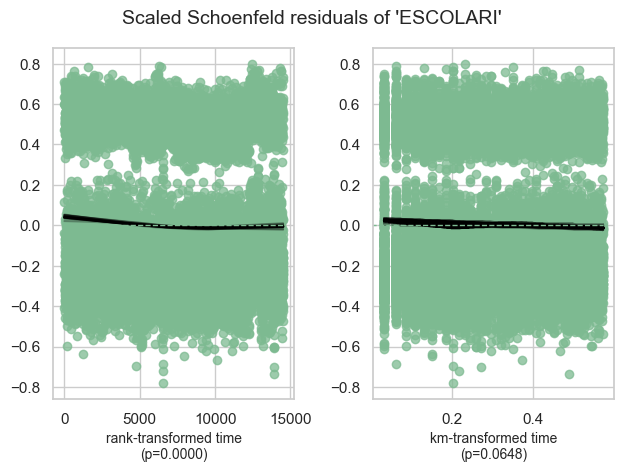

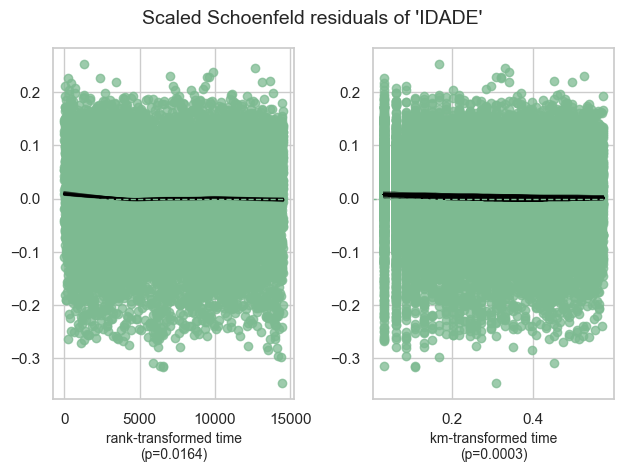

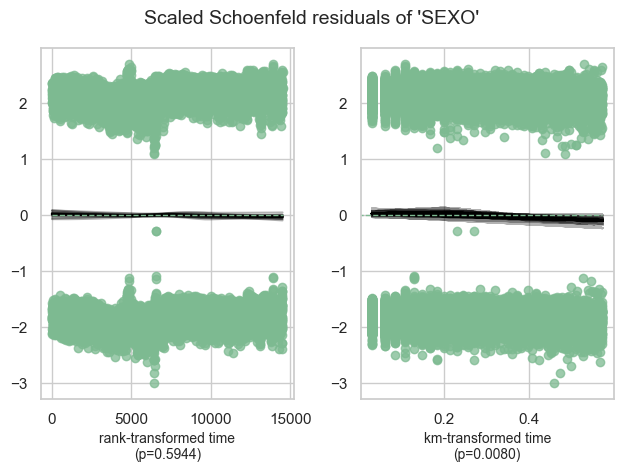

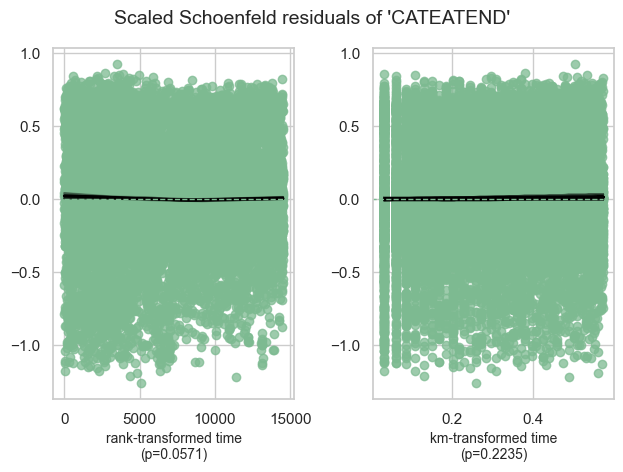

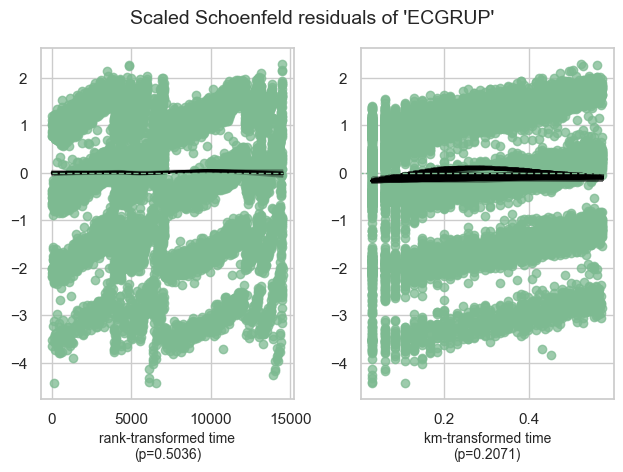

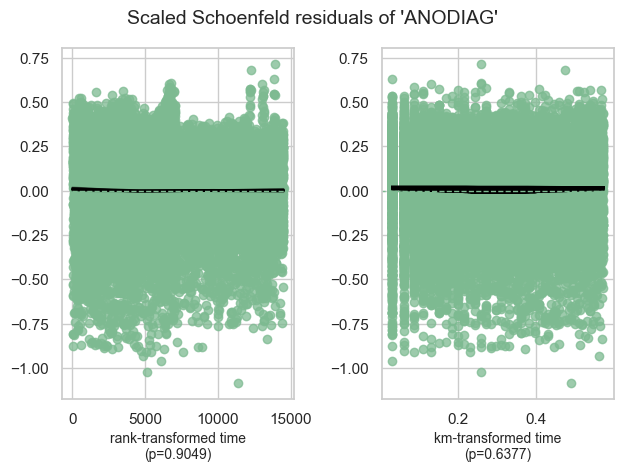

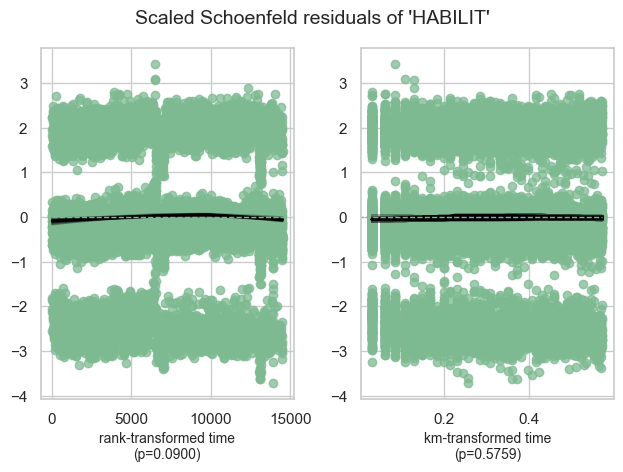

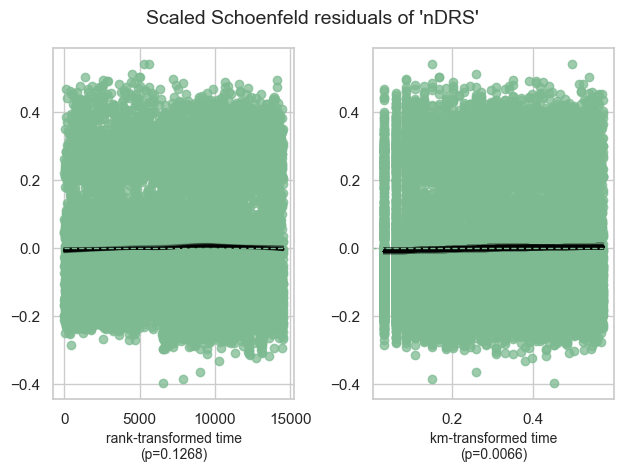

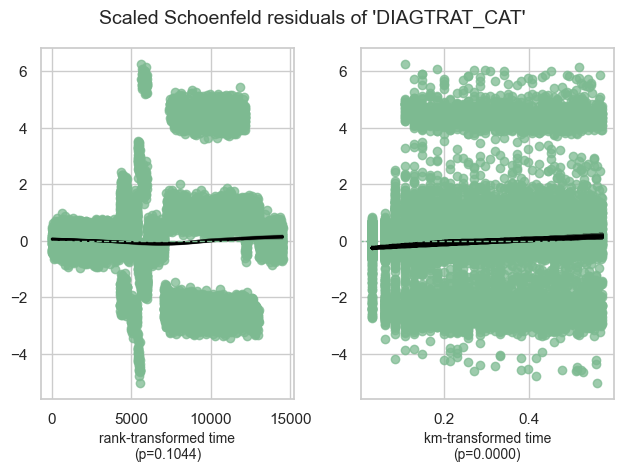

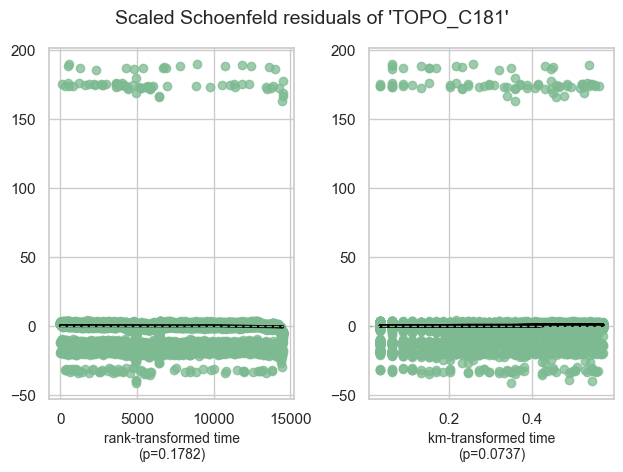

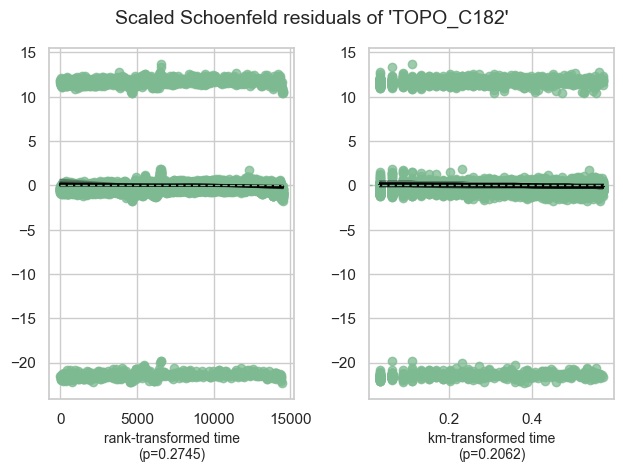

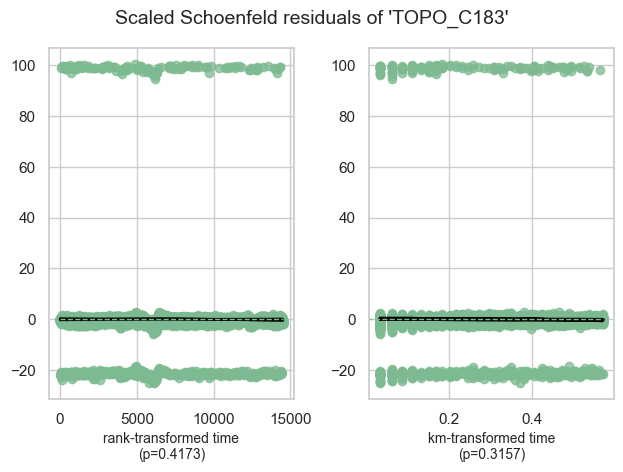

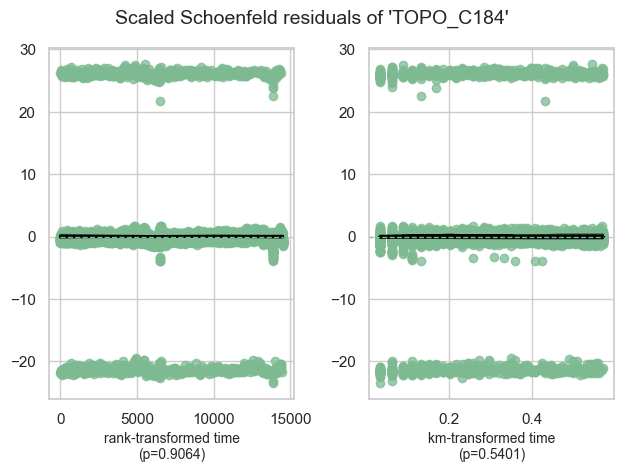

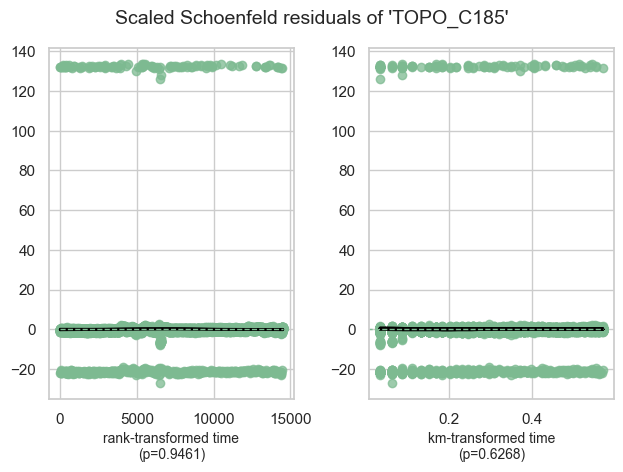

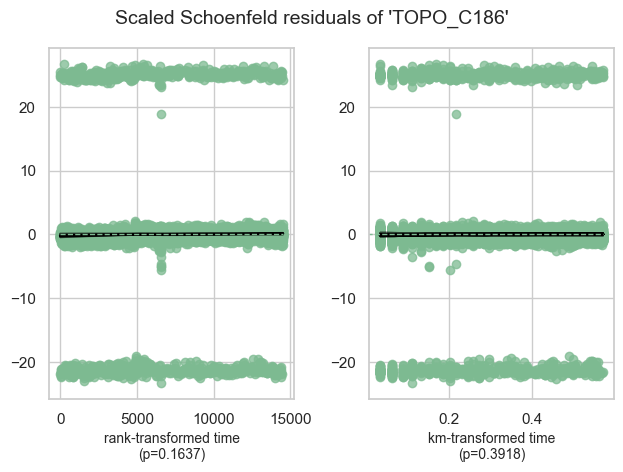

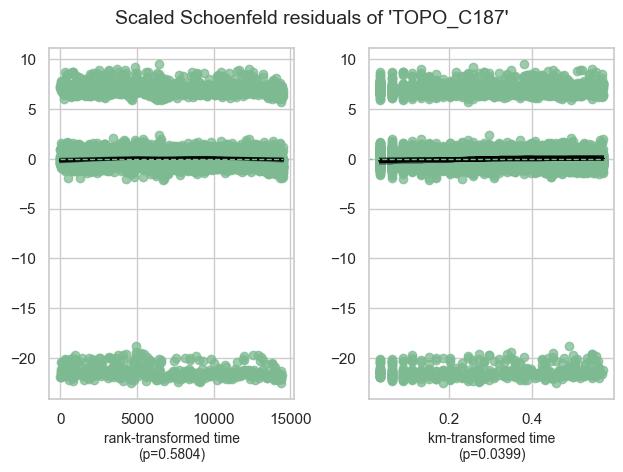

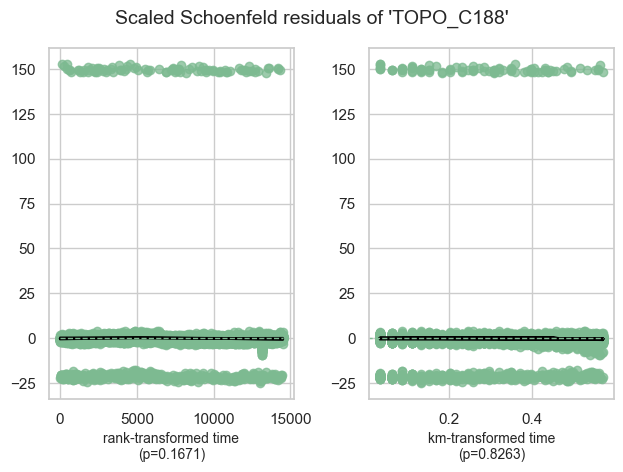

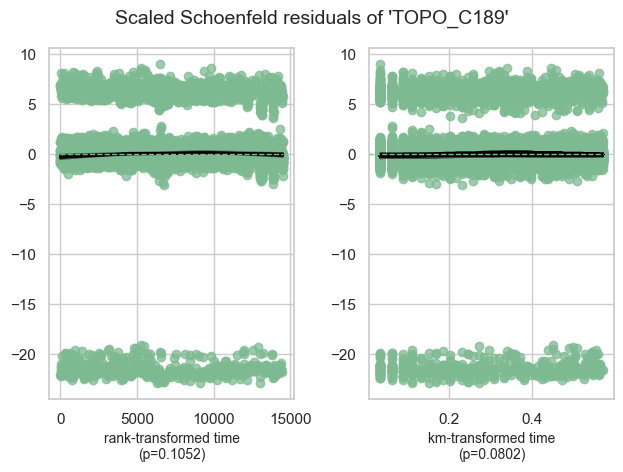

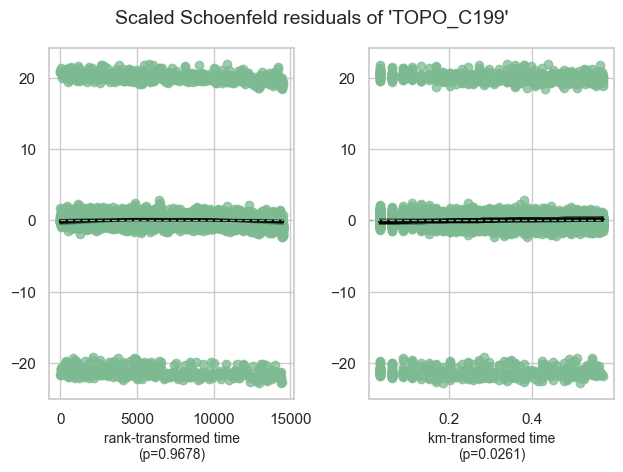

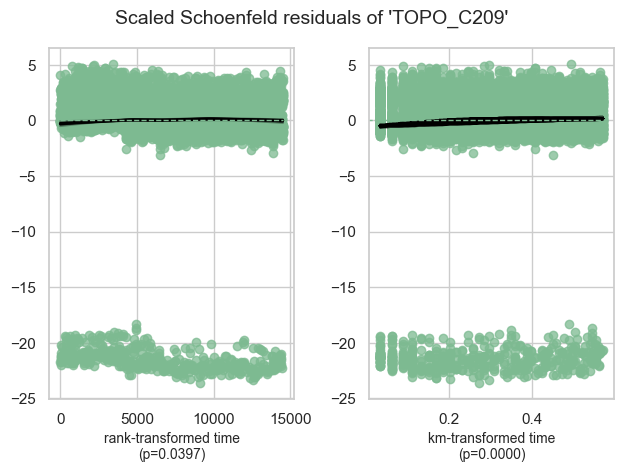

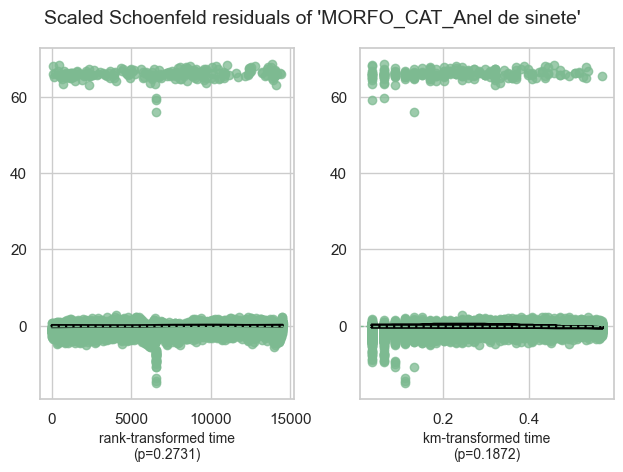

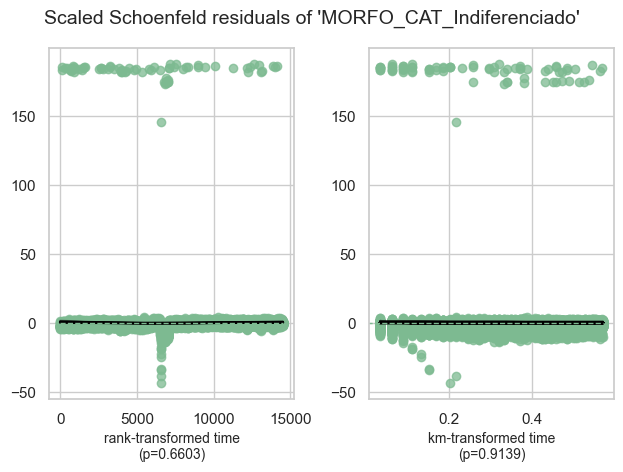

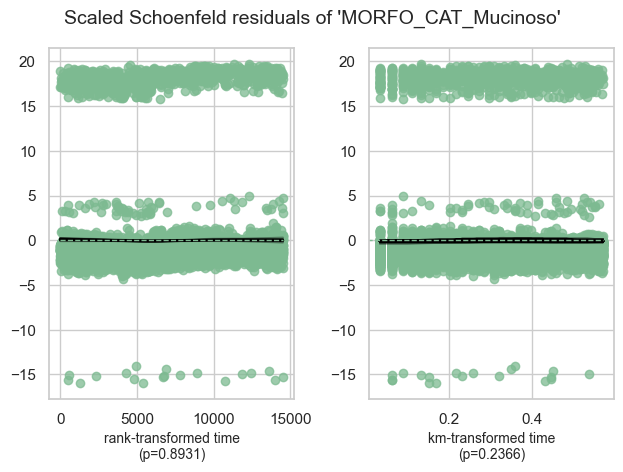

In [15]:
# Checagem das hipóteses do modelo e suas recomendações
cph.check_assumptions(
    df_train_encoded,              # DataSet
    p_value_threshold = 0.05,      # Limiar para dar os alertas
    show_plots = True,             # Mostrar os gráficos
    columns = None                 # Restringe a algumas colunas (lista) ou usa todas as colunas do DataSet
)

### <font color = #007EF5>**Kaplan-Meier por Grupo**</font>


In [16]:
# Função para análise Kaplan-Meier e teste global de log-rank
def plot_kaplan_meier_by_group(df, group_col):
    """
    Descrição:
      Plota curvas de Kaplan-Meier por grupo e apresenta o teste global de log-rank.
    """

    # Ajuste das curvas de sobrevivência por grupo
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(8, 5))

    for group_name, subset in df.groupby(group_col):
        kmf.fit(subset['time'], subset['event'], label=f'{group_col} = {group_name}')
        kmf.plot_survival_function(ci_show=False)

    plt.title(f'Kaplan-Meier por {group_col}')
    plt.xlabel('Tempo (meses)')
    plt.ylabel('Probabilidade de sobrevivência')
    plt.grid(True)
    plt.show()

    # Teste global de log-rank para comparação entre as curvas
    logrank_result = multivariate_logrank_test(df['time'], df[group_col], df['event'])
    print(f'{group_col}: qui-quadrado = {logrank_result.test_statistic:.2f} | p-valor = {logrank_result.p_value:.4g}')


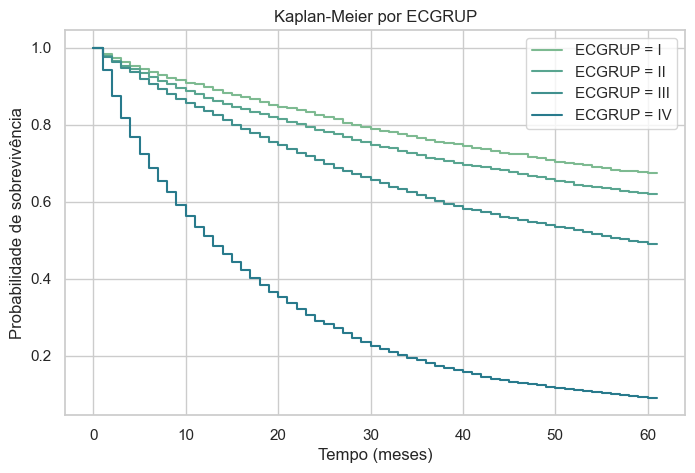

ECGRUP: qui-quadrado = 8698.07 | p-valor = 0


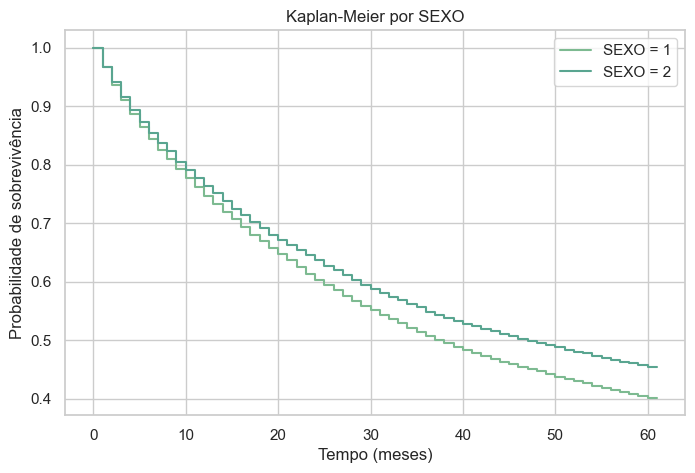

SEXO: qui-quadrado = 63.25 | p-valor = 1.824e-15


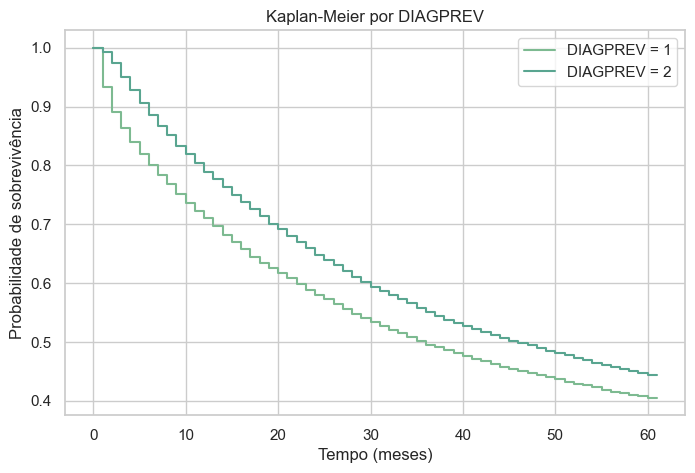

DIAGPREV: qui-quadrado = 104.29 | p-valor = 1.75e-24


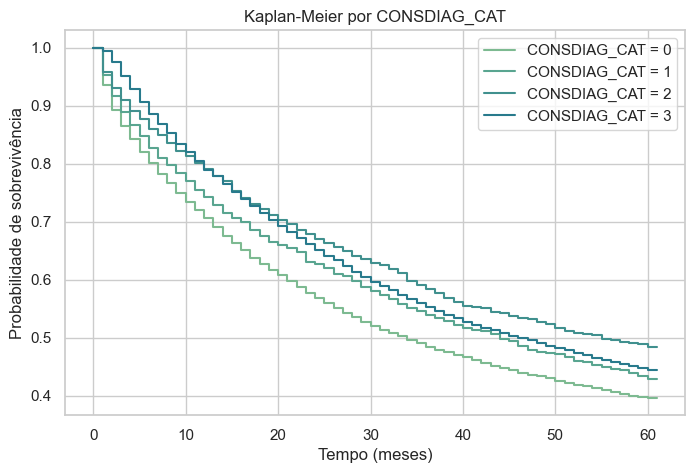

CONSDIAG_CAT: qui-quadrado = 146.95 | p-valor = 1.198e-31


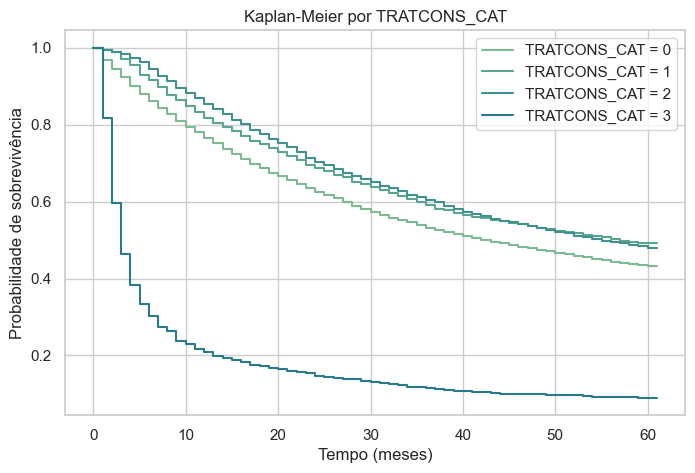

TRATCONS_CAT: qui-quadrado = 3518.33 | p-valor = 0


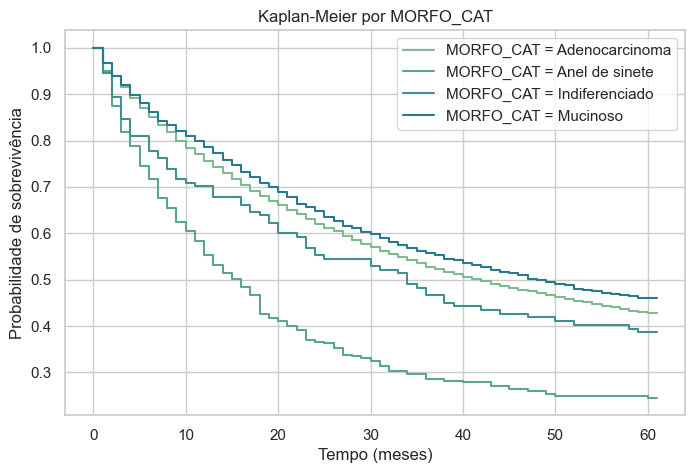

MORFO_CAT: qui-quadrado = 93.69 | p-valor = 3.532e-20


In [17]:
# Aplicação das curvas de Kaplan-Meier nas principais variáveis categóricas
km_group_cols = ['ECGRUP', 'SEXO', 'DIAGPREV', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'MORFO_CAT']

for group_col in km_group_cols:
    plot_kaplan_meier_by_group(df_train, group_col)


### <font color = #007EF5>**Diagnóstico Log(-log(S(t)))**</font>


In [18]:
# Função para inspeção visual da hipótese de riscos proporcionais
def plot_loglog_by_group(df, group_col):
    """
    Descrição:
      Plota log(-log(S(t))) versus log(tempo) para comparar o paralelismo entre grupos.
    """

    # Ajuste das curvas transformadas por grupo
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(8, 5))

    for group_name, subset in df.groupby(group_col):
        kmf.fit(subset['time'], subset['event'], label=f'{group_col} = {group_name}')
        survival_curve = kmf.survival_function_.iloc[:, 0].clip(lower=1e-10, upper=1-1e-10)
        mask = survival_curve.index.to_numpy() > 0
        x_values = np.log(survival_curve.index.to_numpy()[mask])
        y_values = np.log(-np.log(survival_curve.to_numpy()[mask]))
        plt.plot(x_values, y_values, label=f'{group_col} = {group_name}')

    plt.title(f'log(-log(S(t))) por {group_col}')
    plt.xlabel('log(tempo)')
    plt.ylabel('log(-log(S(t)))')
    plt.legend()
    plt.grid(True)
    plt.show()


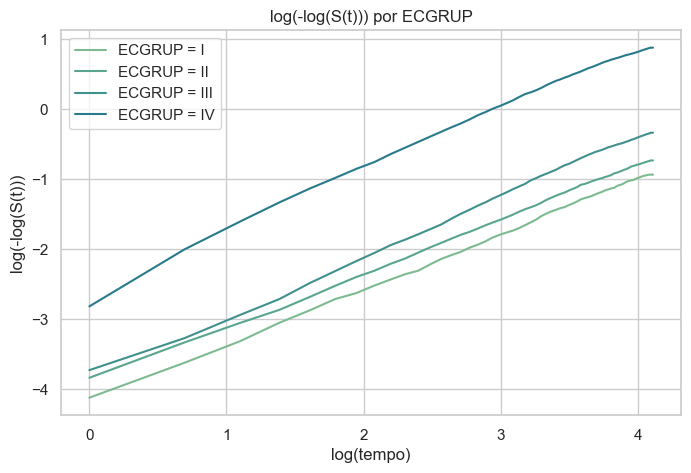

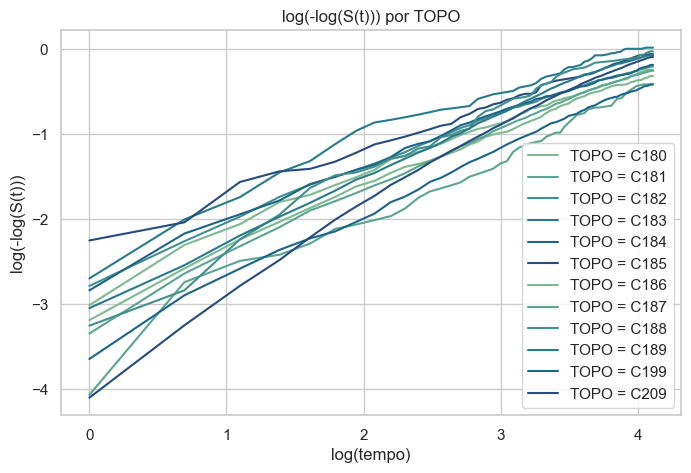

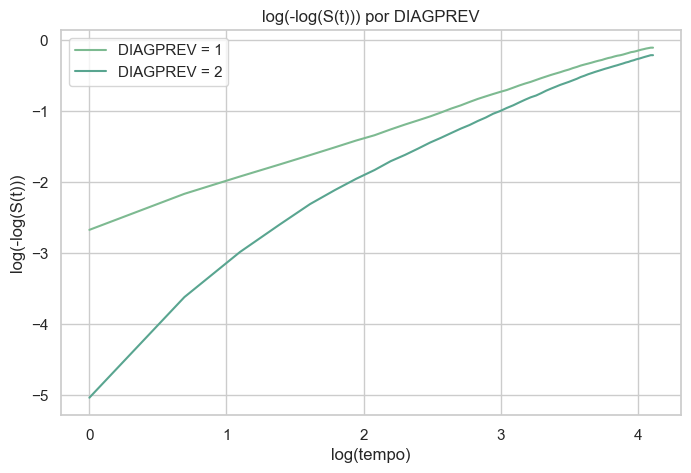

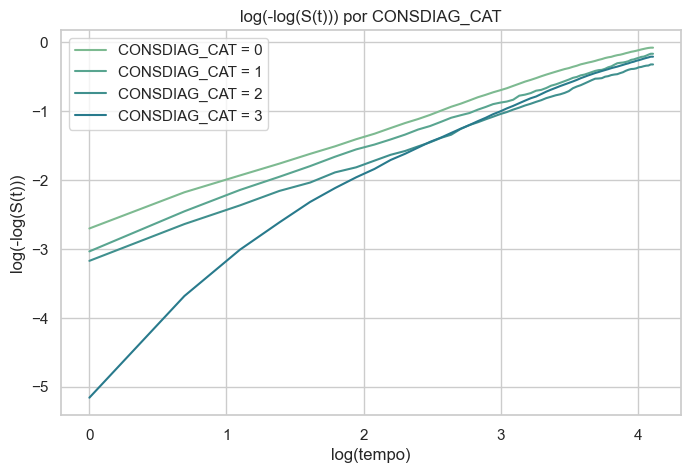

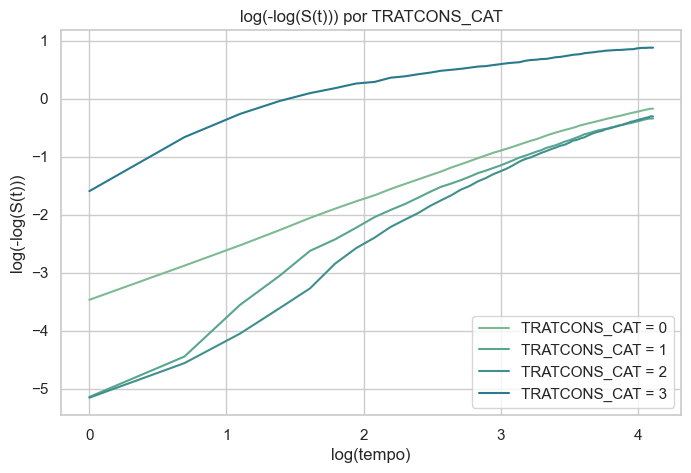

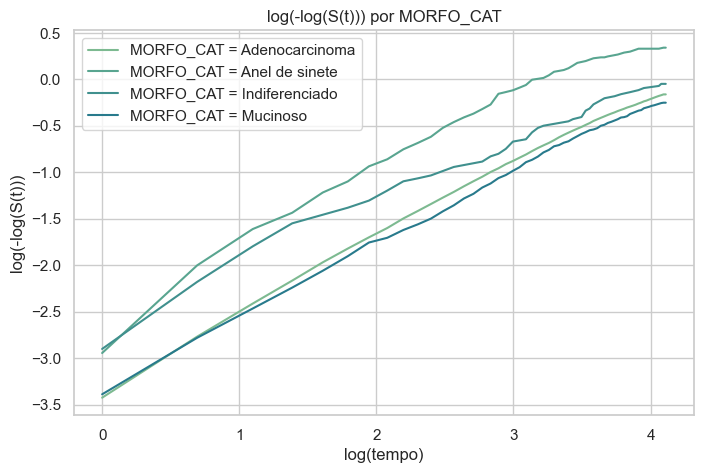

In [19]:
# Aplicação do diagnóstico log-log nas variáveis categóricas principais
loglog_group_cols = ['ECGRUP', 'TOPO', 'DIAGPREV', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'MORFO_CAT']

for group_col in loglog_group_cols:
    plot_loglog_by_group(df_train, group_col)


### <font color = #007EF5>**Resíduos de Martingale**</font>


In [20]:
# Função para avaliar a linearidade de uma variável contínua no modelo de Cox
def plot_martingale_residuals(cph_model, df, continuous_col):
    """
    Descrição:
      Plota resíduos de Martingale para verificar a linearidade de uma variável contínua.
    """

    # Cálculo dos resíduos e curva suavizada de tendência
    residuals = cph_model.compute_residuals(df, kind='martingale').iloc[:, 0].to_numpy()
    x_values = df[continuous_col].to_numpy()
    smooth_x = np.linspace(x_values.min(), x_values.max(), 200)
    smooth_y = np.polyval(np.polyfit(x_values, residuals, deg=2), smooth_x)

    plt.figure(figsize=(8, 5))
    plt.scatter(x_values, residuals, s=10, alpha=0.3)
    plt.plot(smooth_x, smooth_y, color='#F54927', linewidth=2)
    plt.axhline(0, linestyle='--', color='black', linewidth=1)
    plt.title(f'Resíduos de Martingale por {continuous_col}')
    plt.xlabel(continuous_col)
    plt.ylabel('Resíduo de Martingale')
    plt.grid(True)
    plt.show()


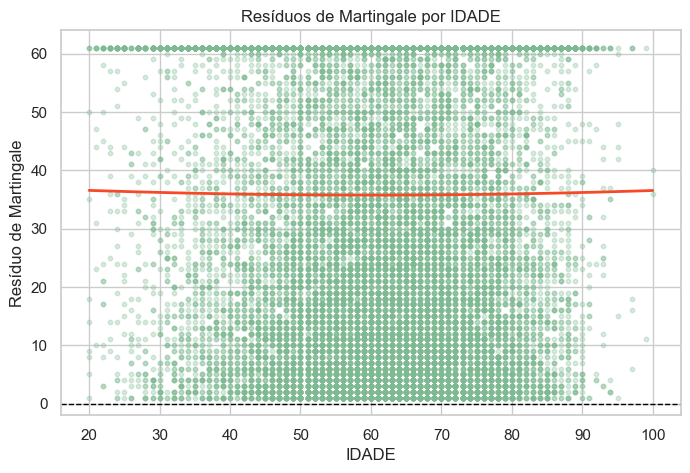

In [21]:
# Aplicação do diagnóstico de Martingale para a idade
plot_martingale_residuals(cph, df_train_encoded, 'IDADE')


## <font color = #B88A00>**Predição e Métricas**</font>


### <font color = #007EF5>**Predição do Tempo Esperado**</font>


In [22]:
# Predição do tempo esperado de sobrevivência para treino e teste
predicted_time_train = cph.predict_expectation(df_train_encoded)
predicted_time_test = cph.predict_expectation(df_test_encoded)

prediction_train = pd.DataFrame(
    {
        'Tempo real': df_train_encoded['time'],
        'Tempo previsto': predicted_time_train,
        'residuo': df_train_encoded['time'] - predicted_time_train
    }
)

prediction_test = pd.DataFrame(
    {
        'Tempo real': df_test_encoded['time'],
        'Tempo previsto': predicted_time_test,
        'residuo': df_test_encoded['time'] - predicted_time_test
    }
)

print('Predições de tempo de sobrevivência para o conjunto de treinamento:')
display(prediction_train.head(5))
print('---' * 20)
print('Predições de tempo de sobrevivência para o conjunto de teste:')
display(prediction_test.head(5))


Predições de tempo de sobrevivência para o conjunto de treinamento:


,Tempo real,Tempo previsto,residuo
0,61,37.678230,23.321770
1,61,47.624496,13.375504
2,2,4.624563,-2.624563
3,1,6.565426,-5.565426
4,6,39.387355,-33.387355


------------------------------------------------------------
Predições de tempo de sobrevivência para o conjunto de teste:


,Tempo real,Tempo previsto,residuo
0,5,39.760769,-34.760769
1,61,43.279367,17.720633
2,8,27.486259,-19.486259
3,61,55.052561,5.947439
4,2,5.730949,-3.730949


#### <font color = #FF120A>**Resumo das Predições**</font>


In [23]:
# Resumo estatístico das predições e dos resíduos
prediction_summary = pd.DataFrame(
    {
        'Treino': [
            prediction_train['Tempo previsto'].min(),
            prediction_train['Tempo previsto'].mean(),
            prediction_train['Tempo previsto'].max(),
            prediction_train['residuo'].mean(),
            prediction_train['residuo'].median()
        ],
        'Teste': [
            prediction_test['Tempo previsto'].min(),
            prediction_test['Tempo previsto'].mean(),
            prediction_test['Tempo previsto'].max(),
            prediction_test['residuo'].mean(),
            prediction_test['residuo'].median()
        ]
    },
    index=[
        'Tempo previsto mínimo',
        'Tempo previsto médio',
        'Tempo previsto máximo',
        'Resíduo médio',
        'Resíduo mediano'
    ]
)

display(prediction_summary.round(4))


,Treino,Teste
Tempo previsto mínimo,0.7658,1.1494
Tempo previsto médio,36.3202,36.3946
Tempo previsto máximo,58.1058,57.4821
Resíduo médio,-0.4953,-0.5554
Resíduo mediano,2.1850,2.0538


### <font color = #007EF5>**Métricas de Desempenho**</font>


In [24]:
# Função para calcular métricas de desempenho do modelo de Cox
def calculate_cox_metrics(cph_model, df_reference, df_target, label, horizon=60):
    """
    Descrição:
      Calcula métricas de discriminação, calibração e erro para o modelo de Cox.
    """

    # Estruturas de sobrevivência para as métricas dependentes de censura
    y_reference = Surv.from_dataframe('event', 'time', df_reference)
    y_target = Surv.from_dataframe('event', 'time', df_target)
    time_grid = np.linspace(6, horizon, 12)

    # Predições do modelo para o conjunto avaliado
    risk_scores = cph_model.predict_partial_hazard(df_target).to_numpy().ravel()
    predicted_time = cph_model.predict_expectation(df_target).to_numpy().ravel()
    survival_curves = cph_model.predict_survival_function(df_target, times=time_grid)
    survival_matrix = survival_curves.T.to_numpy()

    # Consolidação das métricas em uma série nomeada
    return pd.Series(
        {
            'C-Index': cph_model.score(df_target, scoring_method='concordance_index'),
            'C-Index IPCW': concordance_index_ipcw(y_reference, y_target, risk_scores, tau=horizon)[0],
            'IBS': integrated_brier_score(y_reference, y_target, survival_matrix, time_grid),
            'MSE': mean_squared_error(df_target['time'], predicted_time),
            'RMSE': np.sqrt(mean_squared_error(df_target['time'], predicted_time)),
            'MAE': mean_absolute_error(df_target['time'], predicted_time)
        },
        name=label
    )


In [25]:
# Cálculo das métricas para treino e teste
metrics_train = calculate_cox_metrics(cph, df_train_encoded, df_train_encoded, 'Treino')
metrics_test = calculate_cox_metrics(cph, df_train_encoded, df_test_encoded, 'Teste')
metrics_summary = pd.concat([metrics_train, metrics_test], axis=1)
metrics_summary['Diferença'] = metrics_summary['Treino'] - metrics_summary['Teste']

display(metrics_summary.round(4))


,Treino,Teste,Diferença
C-Index,0.6992,0.6961,0.0031
C-Index IPCW,0.6986,0.6955,0.0032
IBS,0.2789,0.2723,0.0065
MSE,409.9518,413.7343,-3.7825
RMSE,20.2473,20.3405,-0.0932
MAE,17.1034,17.1761,-0.0727


## <font color = #B88A00>**Visualizações do Modelo**</font>


### <font color = #007EF5>**Tempo Real vs Previsto**</font>


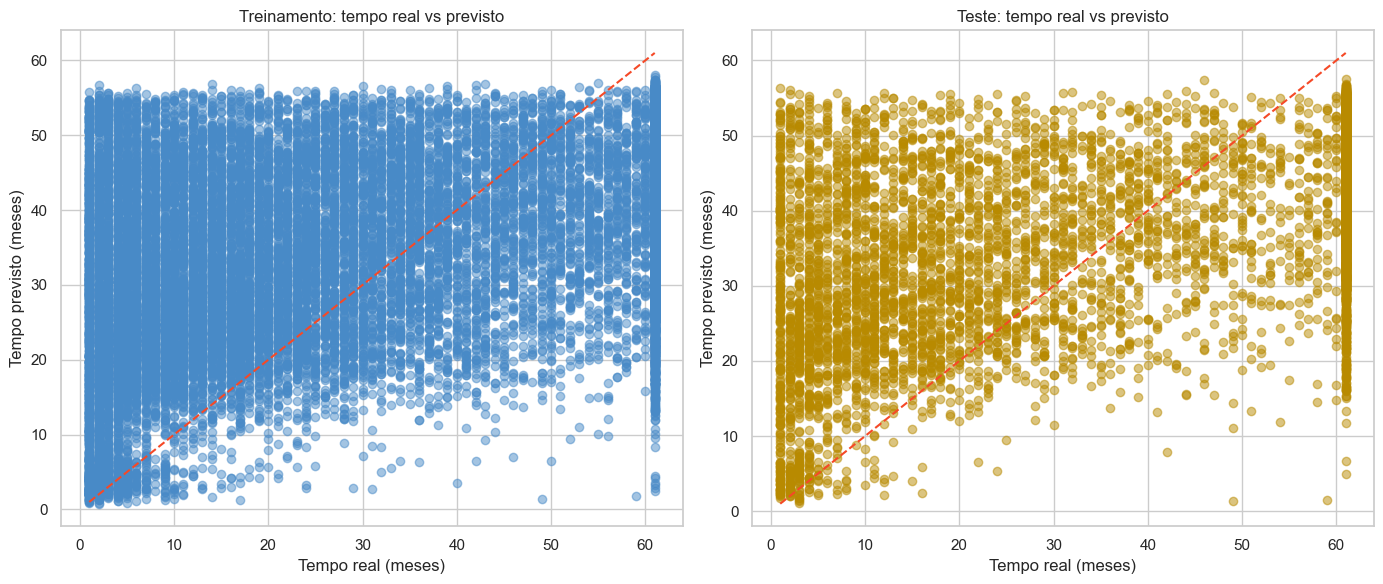

In [26]:
# Comparação entre o tempo observado e o tempo previsto pelo modelo
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(prediction_train['Tempo real'], prediction_train['Tempo previsto'], alpha=0.5, color='#488AC7')
plt.plot(
    [prediction_train['Tempo real'].min(), prediction_train['Tempo real'].max()],
    [prediction_train['Tempo real'].min(), prediction_train['Tempo real'].max()],
    linestyle='--',
    color='#F54927'
)
plt.title('Treinamento: tempo real vs previsto')
plt.xlabel('Tempo real (meses)')
plt.ylabel('Tempo previsto (meses)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(prediction_test['Tempo real'], prediction_test['Tempo previsto'], alpha=0.5, color='#B88A00')
plt.plot(
    [prediction_test['Tempo real'].min(), prediction_test['Tempo real'].max()],
    [prediction_test['Tempo real'].min(), prediction_test['Tempo real'].max()],
    linestyle='--',
    color='#F54927'
)
plt.title('Teste: tempo real vs previsto')
plt.xlabel('Tempo real (meses)')
plt.ylabel('Tempo previsto (meses)')
plt.grid(True)

plt.tight_layout()
plt.show()


### <font color = #007EF5>**Distribuição dos Resíduos**</font>


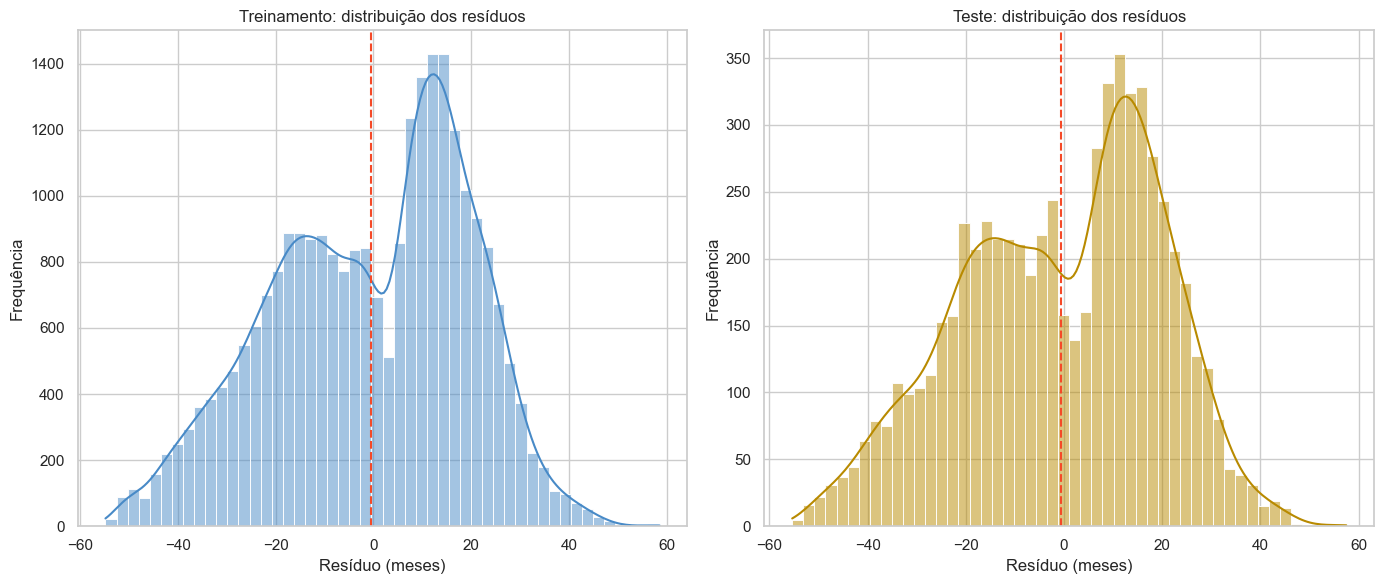

In [27]:
# Distribuição dos resíduos das predições de sobrevivência
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=prediction_train, x='residuo', bins=50, kde=True, color='#488AC7')
plt.axvline(prediction_train['residuo'].mean(), color='#F54927', linestyle='--')
plt.title('Treinamento: distribuição dos resíduos')
plt.xlabel('Resíduo (meses)')
plt.ylabel('Frequência')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.histplot(data=prediction_test, x='residuo', bins=50, kde=True, color='#B88A00')
plt.axvline(prediction_test['residuo'].mean(), color='#F54927', linestyle='--')
plt.title('Teste: distribuição dos resíduos')
plt.xlabel('Resíduo (meses)')
plt.ylabel('Frequência')
plt.grid(True)

plt.tight_layout()
plt.show()


### <font color = #007EF5>**Curva de Kaplan-Meier Geral**</font>


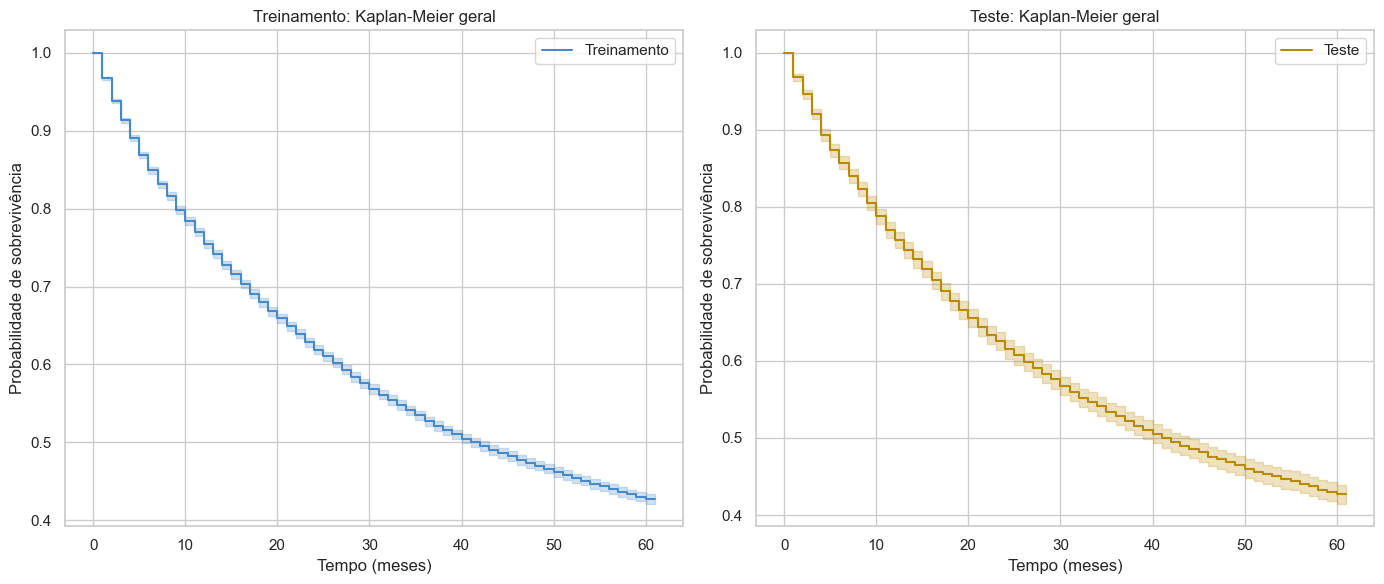

In [28]:
# Curvas gerais de Kaplan-Meier para treino e teste
kmf = KaplanMeierFitter()
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
kmf.fit(df_train['time'], df_train['event'], label='Treinamento')
kmf.plot_survival_function(color='#488AC7')
plt.title('Treinamento: Kaplan-Meier geral')
plt.xlabel('Tempo (meses)')
plt.ylabel('Probabilidade de sobrevivência')
plt.grid(True)

plt.subplot(1, 2, 2)
kmf.fit(df_test['time'], df_test['event'], label='Teste')
kmf.plot_survival_function(color='#B88A00')
plt.title('Teste: Kaplan-Meier geral')
plt.xlabel('Tempo (meses)')
plt.ylabel('Probabilidade de sobrevivência')
plt.grid(True)

plt.tight_layout()
plt.show()


### <font color = #007EF5>**Distribuição do Tempo de Sobrevida**</font>


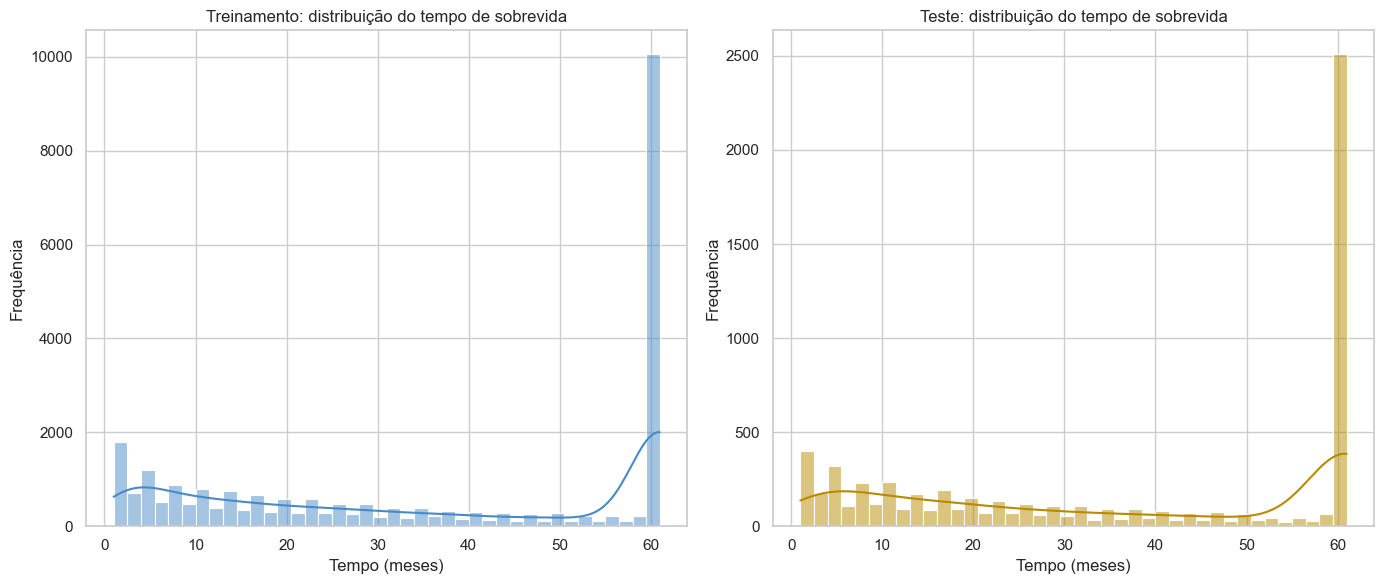

In [29]:
# Distribuição do tempo de sobrevida observado em treino e teste
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df_train, x='time', bins=40, kde=True, color='#488AC7')
plt.title('Treinamento: distribuição do tempo de sobrevida')
plt.xlabel('Tempo (meses)')
plt.ylabel('Frequência')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.histplot(data=df_test, x='time', bins=40, kde=True, color='#B88A00')
plt.title('Teste: distribuição do tempo de sobrevida')
plt.xlabel('Tempo (meses)')
plt.ylabel('Frequência')
plt.grid(True)

plt.tight_layout()
plt.show()


## <font color = #B88A00>**Resultados Consolidados para o Artigo**</font>

Esta seção reúne as saídas finais mais úteis para a escrita do artigo: desempenho, variáveis mais influentes, calibração e síntese interpretativa.


In [ ]:
from IPython.display import Markdown

cox_article_metrics = metrics_summary.rename(
    index={
        'C-Index': 'Índice de concordância',
        'C-Index IPCW': 'Índice de concordância IPCW',
        'IBS': 'Integrated Brier Score',
        'MSE': 'Erro quadrático médio',
        'RMSE': 'Raiz do erro quadrático médio',
        'MAE': 'Erro absoluto médio',
    }
)

cox_feature_effects = (
    cph.summary[['coef', 'exp(coef)', 'se(coef)', 'p']]
    .rename(
        columns={
            'coef': 'Coeficiente',
            'exp(coef)': 'Hazard Ratio',
            'se(coef)': 'Erro padrão',
            'p': 'p-valor',
        }
    )
    .assign(
        **{
            'Influência absoluta': lambda frame: frame['Coeficiente'].abs(),
            'Direção do efeito': lambda frame: np.where(
                frame['Coeficiente'] >= 0,
                'Maior risco',
                'Menor risco'
            ),
        }
    )
    .sort_values('Influência absoluta', ascending=False)
)

ph_violations = (
    ph_test.summary
    .sort_values('p')
    .loc[lambda frame: frame['p'] < 0.05]
    .copy()
)

display(Markdown('### Tabela Final de Desempenho do Modelo de Cox'))
display(cox_article_metrics.round(4))

display(Markdown('### Variáveis com Maior Influência no Modelo'))
display(cox_feature_effects.head(15).round(4))

print('Calibração em 60 meses no conjunto de teste (síntese final)')
survival_probability_calibration(cph, df_test_encoded, t0=60)
plt.title('Calibração do modelo de Cox em 60 meses', pad=12)
plt.show()

violations_text = ', '.join(ph_violations.index.tolist()[:8]) if not ph_violations.empty else 'nenhuma covariável abaixo do limiar adotado'
test_cindex = float(metrics_summary.loc['C-Index', 'Teste'])
test_ipcw = float(metrics_summary.loc['C-Index IPCW', 'Teste'])
test_ibs = float(metrics_summary.loc['IBS', 'Teste'])

discrimination_text = 'aceitável' if test_cindex >= 0.70 and test_ipcw >= 0.70 else 'moderada'
calibration_text = 'globalmente aceitável' if test_ibs < 0.30 else 'ainda com incerteza relevante'
ph_text = 'persistem violações pontuais de PH' if not ph_violations.empty else 'não houve evidência relevante de violação de PH'

conclusion_md = f"""**Síntese final**

- O modelo apresentou discriminação **{discrimination_text}** no conjunto de teste, com `C-Index = {test_cindex:.4f}` e `C-Index IPCW = {test_ipcw:.4f}`.
- A calibração global foi interpretada como **{calibration_text}** à luz do `IBS = {test_ibs:.4f}` e do gráfico de calibração em 60 meses.
- As variáveis com maior influência foram resumidas pela magnitude dos coeficientes e respectivos `hazard ratios`.
- Quanto ao pressuposto de riscos proporcionais, **{ph_text}**. Termos com maior sinal de atenção: {violations_text}.
- Como limitações, permanecem possíveis desvios residuais de calibração e eventuais violações pontuais do pressuposto de PH.
"""

display(Markdown(conclusion_md))
